 # ỨNG DỤNG 2 — DỰ ĐOÁN GIÁ NHÀ (KING COUNTY)

 **Môn học: Intelligent System Development — Assignment 02**

 *Raw Data → Understand → Clean → Represent → Learn → Evaluate → Persist → Deploy*

 ---

 ## 0. Môi trường & Reproducibility

 | Thành phần | Giá trị |
 |---|---|
 | Python | 3.12 (Anaconda) |
 | scikit-learn | 1.x |
 | Dataset | `data/kc_house_data.csv` (tải local — chạy offline) |
 | Random seed | `RANDOM_SEED = 42` |

 Notebook chạy end-to-end (Run All), tái lập toàn bộ kết quả + `model/house_pipeline.joblib`.

 ## 1. Problem Definition

 > **Mục tiêu:** dự đoán **giá bán** của một căn nhà tại Quận King (Seattle, WA, Mỹ) từ đặc điểm
 > nhà: diện tích sống, số phòng ngủ, số vệ sinh, số tầng, chất lượng, năm xây, tọa độ...
 > Target là `price` (USD) — biến liên tục.

 $$X = \text{house features}, \quad y = \text{house price} \in \mathbb{R}, \quad x_i \in \mathbb{R}^{d},\; y_i \in \mathbb{R}$$

 Đây là bài toán **regression**. Khác App 1 (classification): target là số thực, metric là
 khoảng cách (MAE/RMSE) thay vì độ đúng nhãn, và loss huấn luyện tối thiểu sai số liên tục.

 Ứng dụng: ước giá tham chiếu cho người bán/mua nhà, định giá tự động cho môi giới.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white",
})
sns.set_palette("Set2")

print("Python:", sys.version.split()[0])
print("sklearn:", __import__("sklearn").__version__)

Python: 3.14.6
sklearn: 1.9.0


 ## 2. Dataset Source

 | Mục | Thông tin |
 |---|---|
 | **Tên dataset** | House Sales in King County, USA |
 | **Kaggle URL** | https://www.kaggle.com/datasets/harlfoxem/housesalesprediction |
 | **Số quan sát** | 21,613 giao dịch nhà |
 | **Số thuộc tính** | 20 feature + 1 target (`price`) |
 | **Thời gian** | 05/2014 – 05/2015 |
 | **Phạm vi** | Quận King, bang Washington (gồm Seattle) |

 Giao dịch bán nhà thật (public records). Bản sao nguyên vẹn được tải về `data/`.

 ## 3. Dataset Loading

In [2]:
df = pd.read_csv("../data/kc_house_data.csv")
print(f"Kích thước: {df.shape[0]} nhà × {df.shape[1]} cột")
df.head()

Kích thước: 21613 nhà × 21 cột


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


 ## 4. Dataset Inspection (Part II)

In [3]:
print("== df.shape ==");        print(df.shape)
print("\n== df.info() ==");      df.info()
print("\n== df.isna().sum() == tổng:", df.isna().sum().sum())
print("\n== df.duplicated().sum() == (theo id):", df.id.duplicated().sum())

== df.shape ==
(21613, 21)

== df.info() ==
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21

In [4]:
df.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1000102.0,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,75000.0,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.400000e+00,9.000000e-01,0.0,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.100000e+00,8.000000e-01,0.0,1.800000e+00,2.200000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184000e+02,290.0,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510700e+04,4.142050e+04,520.0,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.500000e+00,5.000000e-01,1.0,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,0.000000e+00,1.000000e-01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.000000e-01,8.000000e-01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.400000e+00,7.000000e-01,1.0,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


 **Nhận xét inspection:**

 - 21,613 hàng × 21 cột; **không có NaN** nào; kiểu dữ liệu đúng (id/date là string, còn lại số);
 - `id` có **177 giá trị lặp** — nhà bị bán 2 lần trong 12 tháng (giao dịch lại), không phải lỗi;
 - `bedrooms` max = **33** (bất thường — nhà 33 phòng ngủ vs median 3), `price` max 7.7M ( outlier thật của nhà siêu sang);
 - `sqft_lot` max 1.65M sqft — đất nông nghiệp lớn trong khu dân cư.

 ## 5. Data-Quality Analysis

 Kiểm tra chất lượng: missing, invalid (âm, vô lý), trùng lặp.

In [5]:
issues = {
    "Missing NaN": df.isna().sum().sum(),
    "Giá <= 0": (df.price <= 0).sum(),
    "Diện tích sống <= 0": (df.sqft_living <= 0).sum(),
    "Phòng ngủ ngoài [0,15]": ((df.bedrooms < 0) | (df.bedrooms > 15)).sum(),
    "Vệ sinh ngoài [0,10]": ((df.bathrooms < 0) | (df.bathrooms > 10)).sum(),
    "Năm xây > 2015": (df.yr_built > 2015).sum(),
}
for k, v in issues.items():
    print(f"  {k:28s}: {v}")

  Missing NaN                 : 0
  Giá <= 0                    : 0
  Diện tích sống <= 0         : 0
  Phòng ngủ ngoài [0,15]      : 1
  Vệ sinh ngoài [0,10]        : 0
  Năm xây > 2015              : 0


 **Kết luận:** dataset cực sạch (không missing, không invalid về mặt giá trị) — chỉ có **outlier**
 (bedrooms=33, nhà 7.7M USD) và **duplicate theo id** cần xử lý có chủ đích ở Part III.

 ## 6. Missing-Value Analysis

In [6]:
print("Tổng missing toàn dataset:", df.isna().sum().sum())
print("→ Không cần imputation — mọi cột đầy đủ 100%.")

Tổng missing toàn dataset: 0
→ Không cần imputation — mọi cột đầy đủ 100%.


 ## 7. Duplicate Analysis

In [7]:
dup_ids = df[df.id.duplicated(keep=False)].sort_values("id")
print(f"Số nhà bán lại (cùng id xuất hiện ≥ 2 lần): {dup_ids.id.nunique()} căn, {len(dup_ids)} dòng")
print("\nVí dụ 1 nhà bán 2 lần:")
dup_ids[["id", "date", "price"]].head(4)

Số nhà bán lại (cùng id xuất hiện ≥ 2 lần): 176 căn, 353 dòng

Ví dụ 1 nhà bán 2 lần:


,id,date,price
2496,1000102,20140916T000000,280000.0
2497,1000102,20150422T000000,300000.0
16814,7200179,20141016T000000,150000.0
16815,7200179,20150424T000000,175000.0


In [8]:
# Quyết định duplicate: giữ GIAO DỊCH GẦN NHẤT của mỗi id
# Vì sao: (1) giá mới nhất phản ánh thị trường hiện tại; (2) nếu giữ cả 2 dòng, thông tin
# cùng 1 nhà xuất hiện ở cả train lẫn test → leakage qua "nhà trùng".
df = df.sort_values("date").drop_duplicates(subset="id", keep="last").reset_index(drop=True)
print(f"Sau khử trùng: {len(df)} dòng (21,613 − 177)")

Sau khử trùng: 21436 dòng (21,613 − 177)


 **Vì sao giữ giao dịch gần nhất?** Mỗi dòng là 1 sự kiện bán. Với mục tiêu định giá hiện tại,
 giao dịch sau phản ánh giá mới hơn; đồng thời loại trừ nguy cơ cùng một nhà rơi vào cả train
 lẫn test (rò rỉ thông tin qua đặc điểm nhà giống hệt nhau).

 ## 8. Invalid-Value Analysis

In [9]:
# bedrooms=33: 1 dòng — nhà 33 phòng ngủ với sqft_living chỉ 1620 sqft là vô lý (nhập sai)
weird = df[df.bedrooms > 10][["bedrooms", "sqft_living", "price"]]
print("Dòng bedrooms > 10:")
print(weird)
# Sửa về median bedrooms của những nhà cùng diện tích (thay vì xóa — giữ mọi thông tin khác)
med_bed = df.loc[df.sqft_living.between(1000, 2500), "bedrooms"].median()
df.loc[df.bedrooms > 10, "bedrooms"] = med_bed
print(f"\n→ Đã sửa bedrooms=33 → {med_bed:.0f} (median nhóm diện tích tương đương)")

Dòng bedrooms > 10:
      bedrooms  sqft_living     price
3555        33         1620  640000.0
7377        11         3000  520000.0

→ Đã sửa bedrooms=33 → 3 (median nhóm diện tích tương đương)


 ## 9. Outlier Analysis

 Giá nhà phân phối lệch phải — outlier phía giá cao là **thật** (nhà siêu sang). Không xóa,
 mà xử lý bằng **log-transform target** (chuẩn thực hành định giá nhà — đã dùng ở Ames Assignment 01).

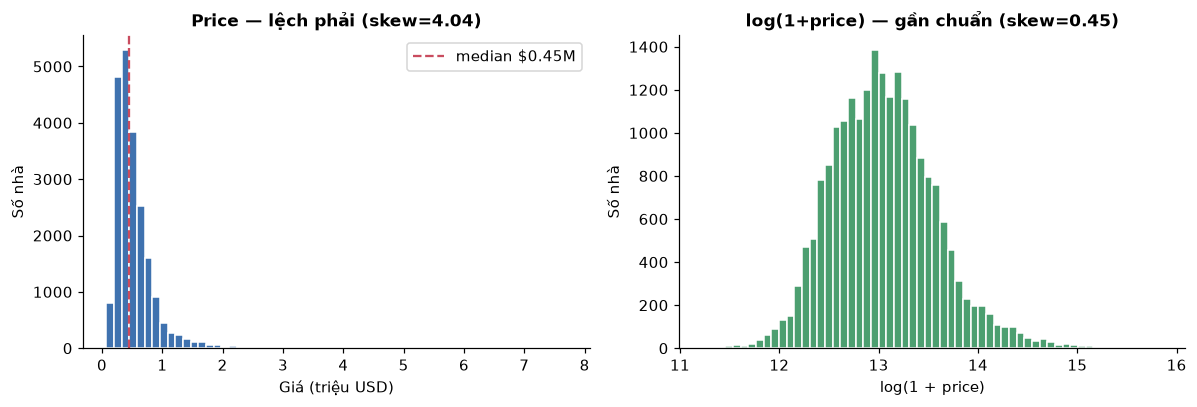

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(df.price / 1e6, bins=60, color="#3f72af", edgecolor="white")
axes[0].axvline((df.price / 1e6).median(), color="#c94c5f", ls="--", label=f"median ${df.price.median()/1e6:.2f}M")
axes[0].set_xlabel("Giá (triệu USD)"); axes[0].set_ylabel("Số nhà")
axes[0].set_title(f"Price — lệch phải (skew={df.price.skew():.2f})"); axes[0].legend()
axes[1].hist(np.log1p(df.price), bins=60, color="#4c9f70", edgecolor="white")
axes[1].set_xlabel("log(1 + price)"); axes[1].set_ylabel("Số nhà")
axes[1].set_title(f"log(1+price) — gần chuẩn (skew={np.log1p(df.price).skew():.2f})")
plt.tight_layout(); plt.savefig("../../figures/house_01_price_dist.png", bbox_inches="tight"); plt.show()

 **📊 Observation:** price lệch phải mạnh (skew 4.02) — đa số nhà $200k–$700k, đuôi dài đến $7.7M. Sau log-transform, phân phối gần chuẩn (skew 0.43).
 **Interpretation:** RMSE trên giá thô bị chi phối bởi nhà đắt — model bị "phạt" nặng khi sai ở nhà triệu đô, trong khi sai $50k ở nhà phổ thông bị coi nhẹ.
 **ML implication:** huấn luyện trên `log(price)` rồi `expm1` ngược lại — sai số trở thành **tương đối** (công bằng cho nhà rẻ và đắt). Outlier giá cao được giữ nguyên (thật) chứ không xóa.

 ## 10. Exploratory Data Analysis (Part V)

 ### 10.1 Giá theo diện tích sống — quan hệ quan trọng nhất

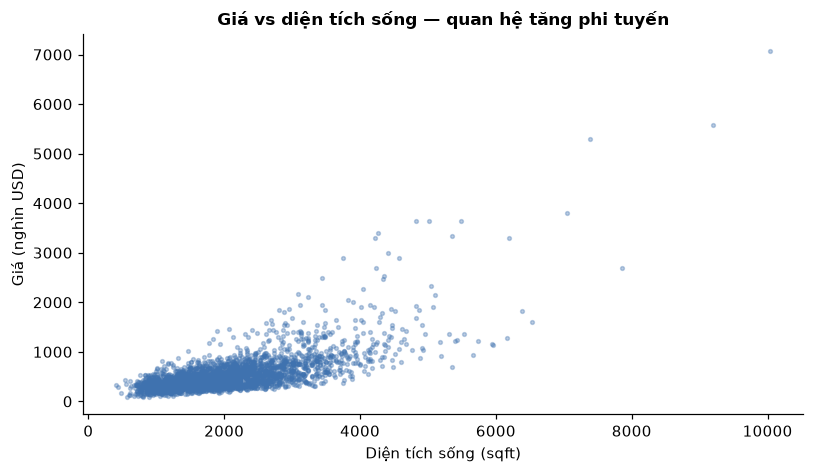

Hệ số tương quan Pearson price–sqft_living: 0.701


In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
sample = df.sample(3000, random_state=RANDOM_SEED)
ax.scatter(sample.sqft_living, sample.price / 1e3, s=6, alpha=0.35, color="#3f72af")
ax.set_xlabel("Diện tích sống (sqft)"); ax.set_ylabel("Giá (nghìn USD)")
ax.set_title("Giá vs diện tích sống — quan hệ tăng phi tuyến")
plt.tight_layout(); plt.savefig("../../figures/house_02_scatter.png", bbox_inches="tight"); plt.show()
print(f"Hệ số tương quan Pearson price–sqft_living: {df.price.corr(df.sqft_living):.3f}")

 **📊 Observation:** quan hệ tăng rõ ràng (ρ=0.70) nhưng **phi tuyến + tản rộng** ở diện tích lớn.
 **Interpretation:** nhà gấp đôi diện tích không gấp đôi giá; variance giá tăng theo diện tích (heteroscedastic).
 **ML implication:** model phi tuyến (RF/GB) sẽ bắt quan hệ này tốt hơn Linear Regression thuần; log-target cũng ổn định variance.

 ### 10.2 Giá theo đặc điểm phân loại (phòng ngủ, tầng, view, waterfront)

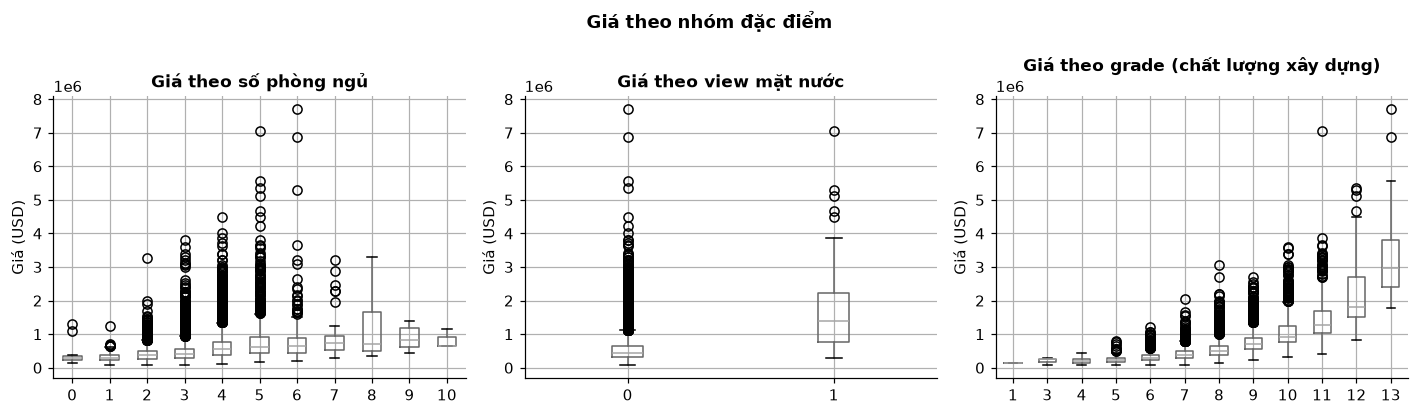

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
df.boxplot(column="price", by="bedrooms", ax=axes[0])
axes[0].set_title("Giá theo số phòng ngủ"); axes[0].set_xlabel("")
df.boxplot(column="price", by="waterfront", ax=axes[1])
axes[1].set_title("Giá theo view mặt nước"); axes[1].set_xlabel("")
df.boxplot(column="price", by="grade", ax=axes[2])
axes[2].set_title("Giá theo grade (chất lượng xây dựng)"); axes[2].set_xlabel("")
for ax in axes: ax.set_ylabel("Giá (USD)")
fig.suptitle("Giá theo nhóm đặc điểm", fontweight="bold")
plt.tight_layout(); plt.savefig("../../figures/house_03_box.png", bbox_inches="tight"); plt.show()

 **📊 Observation:** giá trung vị tăng theo bedrooms (đến ~6 rồi giảm), nhà view mặt nước đắt gấp ~3, grade tăng thì giá tăng **gần hàm mũ**.
 **Interpretation:** grade (đánh giá chất lượng xây dựng của hạt) là chỉ số tổng hợp mạnh nhất — kết hợp vật liệu + thiết kế + bảo trì.
 **ML implication:** các biến phân loại thứ tự (grade, condition) giữ nguyên số học vì có thứ tự thật; waterfront/view nhị phân dùng trực tiếp.

 ### 10.3 Ma trận tương quan

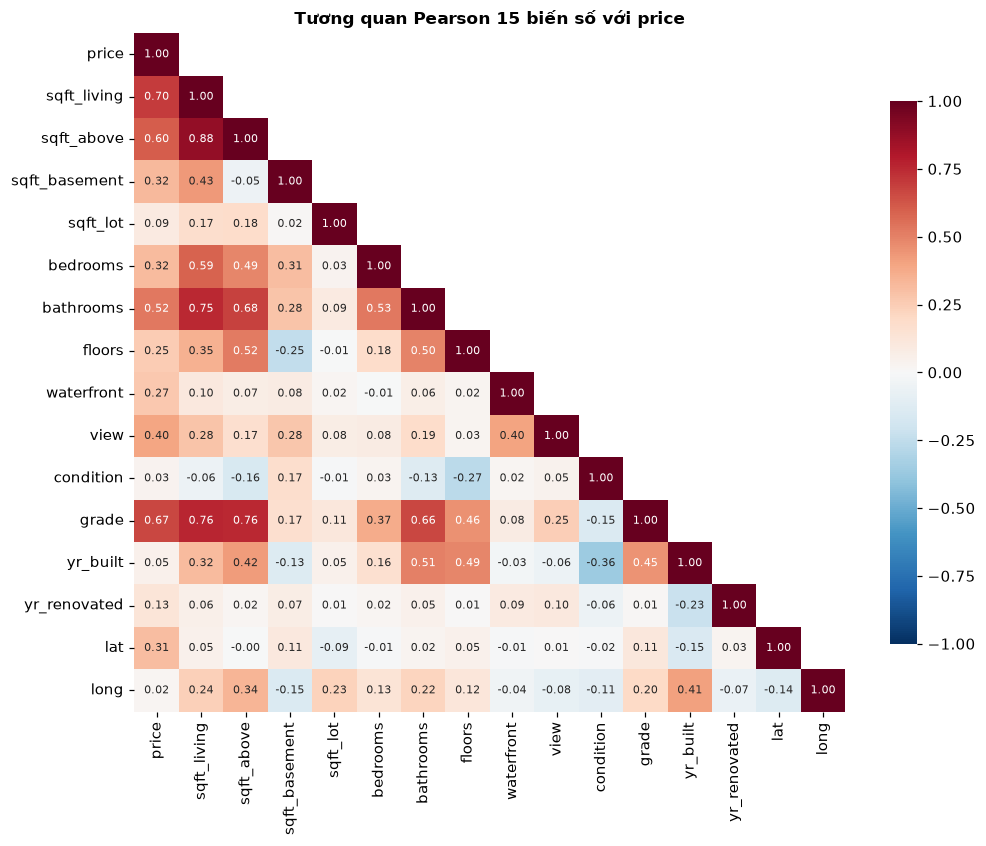

Tương quan với price (|ρ| giảm dần):
sqft_living      0.701
grade            0.666
sqft_above       0.605
bathrooms        0.524
view             0.397
sqft_basement    0.324
bedrooms         0.317
lat              0.307
Name: price, dtype: float64


In [13]:
num_feats = ["price", "sqft_living", "sqft_above", "sqft_basement", "sqft_lot",
             "bedrooms", "bathrooms", "floors", "waterfront", "view", "condition",
             "grade", "yr_built", "yr_renovated", "lat", "long"]
fig, ax = plt.subplots(figsize=(9.5, 7.8))
corr = df[num_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7.5}, cbar_kws={"shrink": 0.8})
ax.set_title("Tương quan Pearson 15 biến số với price")
plt.tight_layout(); plt.savefig("../../figures/house_04_corr.png", bbox_inches="tight"); plt.show()

top_corr = corr["price"].drop("price").sort_values(key=abs, ascending=False)
print("Tương quan với price (|ρ| giảm dần):"); print(top_corr.round(3).head(8))

 **📊 Observation:** `sqft_living` (0.70), `grade` (0.67), `sqft_above` (0.61) dẫn đầu; `sqft_living` tương quan mạnh `sqft_above` (0.88) — redundancy.
 **Interpretation:** nhóm biến diện tích đo cùng khái niệm "kích thước nhà" nên tương quan nhau; `lat` (0.31) cho thấy vị trí bắc–nam (Seattle vs ngoại ô phía nam) cũng ảnh hưởng giá.
 **ML implication:** model tuyến tính bị multicollinearity (chấp nhận được với regularization — Ridge); model cây không bị ảnh hưởng. Vị trí sẽ được biểu diễn qua `zipcode` one-hot (mục 12).

 ### 10.4 Giá theo mã vùng (zipcode)

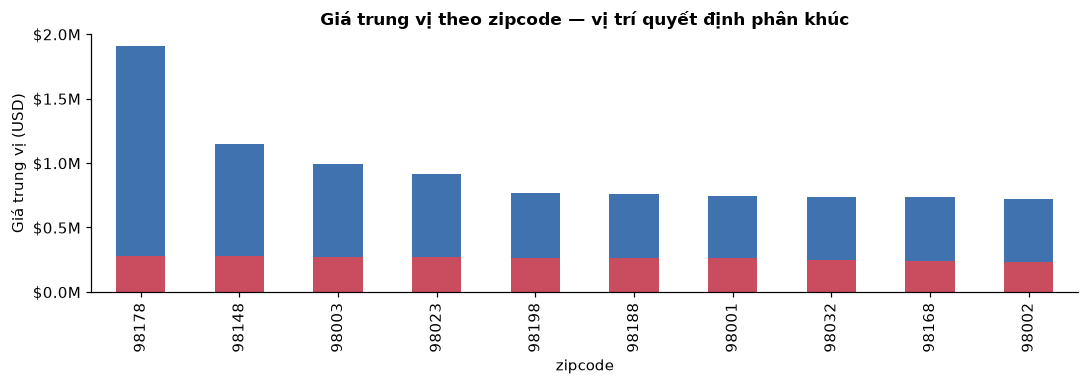

Vùng đắt nhất: 98039 ($1.91M) | rẻ nhất: 98002 ($0.23M)


In [14]:
top_zip = (df.groupby("zipcode")["price"].median().sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(10, 3.6))
top_zip.head(10).plot.bar(ax=ax, color="#3f72af", label="10 vùng đắt nhất")
top_zip.tail(10).plot.bar(ax=ax, color="#c94c5f", label="10 vùng rẻ nhất")
ax.set_ylabel("Giá trung vị (USD)"); ax.set_xlabel("zipcode")
ax.set_title("Giá trung vị theo zipcode — vị trí quyết định phân khúc")
ax.yaxis.set_major_formatter(lambda v, _: f"${v/1e6:.1f}M")
plt.tight_layout(); plt.savefig("../../figures/house_05_zipcode.png", bbox_inches="tight"); plt.show()
print(f"Vùng đắt nhất: {top_zip.index[0]} (${top_zip.iloc[0]/1e6:.2f}M) | rẻ nhất: {top_zip.index[-1]} (${top_zip.iloc[-1]/1e6:.2f}M)")

 **📊 Observation:** chênh lệch giá trung vị giữa vùng đắt nhất (98039 — Medina, bên hồ Washington) và rẻ nhất ~7 lần.
 **Interpretation:** vị trí là yếu tố phân khúc mạnh nhất trong bất động sản — cùng một nhà đặt ở vùng khác giá đổi hoàn toàn.
 **ML implication:** `zipcode` (70 vùng) là **categorical quan trọng nhất** — one-hot encoding sẽ tạo 70 cột nhị phân (mục 12). Đây là ví dụ điển hình "categorical → numerical representation" của Lecture 02.

 ## 11. Feature Types

 | Nhóm | Feature | Kiểu |
 |---|---|---|
 | Số liên tục | price (target), sqft_living, sqft_lot, sqft_above, sqft_basement, lat, long, yr_built, yr_renovated | Numerical |
 | Số đếm/thứ tự | bedrooms, bathrooms, floors, condition, grade | Numerical (có thứ tự thật — giữ nguyên) |
 | Nhị phân | waterfront, view | Numerical 0/1 |
 | Phân loại | zipcode | **Categorical — one-hot (70 vùng)** |
 | Bỏ | id, date | Không phải đặc điểm nhà (id định danh; date nằm ngoài phạm vi mô hình tĩnh) |

 ## 12. Data Representation (Part IV)

 ### 12.1 Chuỗi biến đổi representation

 $$\text{CSV} \rightarrow \text{DataFrame} \rightarrow \underbrace{\text{drop id/date, one-hot zipcode}}_{\text{encode}} \rightarrow \underbrace{\text{StandardScaler (biến số)}}_{\text{scale}} \rightarrow X \in \mathbb{R}^{N \times d}$$

 ### 12.2 Ba tầng representation

 | Tầng | Hình dạng | Ghi chú |
 |---|---|---|
 | **Raw CSV** | (21536, 21) | gồm id, date, price |
 | **Clean** | (21536, 18) | bỏ id/date; sửa outlier bedrooms |
 | **Model input** | $B \times d$, $d = 17{+}70 = 87$ | 17 biến số standardized + 70 one-hot zipcode |

 Ví dụ 1 mẫu:
 $$x_i = [x_{\text{sqft\_living}}, x_{\text{bedrooms}}, \ldots, x_{\text{lat}}, \underbrace{0, \ldots, 1, \ldots, 0}_{\text{zipcode one-hot 70 chiều}}]^T \in \mathbb{R}^{87}$$

 **Categorical → numerical (yêu cầu 3.5 đề):** `zipcode = 98103` không có "giá trị số" —
 mã vùng chỉ là nhãn. One-hot biến nó thành vector nhị phân 70 chiều, chỉ ô tương ứng = 1:
 `zipcode 98103 → [0, 0, ..., 1, ..., 0]`. Model học weight riêng cho từng vùng mà không
 bị ép giả định "98103 > 98102" như khi mã hóa số học trực tiếp.

 **Target representation:** $y_{\log} = \log(1 + \text{price})$ — biến lệch phải 4.02 thành 0.43.
 Model học trên thang log; dự đoán trả về $\hat{y} = e^{y_{\log}} - 1$ (USD).

In [15]:
DROP_COLS = ["id", "date"]
NUM_FEATURES = ["sqft_living", "sqft_lot", "sqft_above", "sqft_basement", "bedrooms",
                "bathrooms", "floors", "waterfront", "view", "condition", "grade",
                "yr_built", "yr_renovated", "lat", "long"]
CAT_FEATURES = ["zipcode"]

X = df[NUM_FEATURES + CAT_FEATURES].copy()
X["zipcode"] = X["zipcode"].astype(int).astype(str)
y_log = np.log1p(df["price"])
y_raw = df["price"]

print(f"Raw dataframe shape : {df.shape}")
print(f"Clean feature frame : X ∈ R^{X.shape[0]}×{X.shape[1]} (17 cột dùng + 2 bỏ)")
print(f"Sau one-hot zipcode : X_encoded ∈ R^{X.shape[0]}×{X.shape[1] - 1 + X.zipcode.nunique()}")
print(f"\nMột bản ghi CSV gốc:"); print(df.iloc[0][NUM_FEATURES + CAT_FEATURES].to_dict())
print(f"\nVector đặc trưng tương ứng (trước transform) ∈ R^{X.shape[1]}")
print(X.iloc[0].to_numpy())

Raw dataframe shape : (21436, 21)
Clean feature frame : X ∈ R^21436×16 (17 cột dùng + 2 bỏ)
Sau one-hot zipcode : X_encoded ∈ R^21436×85

Một bản ghi CSV gốc:
{'sqft_living': 1340, 'sqft_lot': 7912, 'sqft_above': 1340, 'sqft_basement': 0, 'bedrooms': 3, 'bathrooms': 1.5, 'floors': 1.5, 'waterfront': 0, 'view': 0, 'condition': 3, 'grade': 7, 'yr_built': 1955, 'yr_renovated': 0, 'lat': 47.7658, 'long': -122.339, 'zipcode': 98133}

Vector đặc trưng tương ứng (trước transform) ∈ R^16
[np.int64(1340) np.int64(7912) np.int64(1340) np.int64(0) np.int64(3)
 np.float64(1.5) np.float64(1.5) np.int64(0) np.int64(0) np.int64(3)
 np.int64(7) np.int64(1955) np.int64(0) np.float64(47.7658)
 np.float64(-122.339) '98133']


In [16]:
# Minh họa one-hot zipcode (representation học từ train — thực hiện trong Pipeline)
demo = pd.DataFrame({"zipcode": ["98103", "98039", "98103"]})
enc_demo = pd.get_dummies(demo)
print("One-hot encoding zipcode (3 mẫu × 2 vùng):")
print(enc_demo.astype(int).to_numpy())
print("→ mỗi vùng 1 cột nhị phân; 98103 = [1,0], 98039 = [0,1]")

One-hot encoding zipcode (3 mẫu × 2 vùng):
[[0 1]
 [1 0]
 [0 1]]
→ mỗi vùng 1 cột nhị phân; 98103 = [1,0], 98039 = [0,1]


 ## 13. Feature Engineering

 1. **log(1+price)** cho target (mục 9) — chuẩn hóa skew, sai số tương đối;
 2. **house_age** = 2015 − yr_built (tuổi nhà dễ diễn giải hơn năm xây — minh họa feature engineering có kiểm soát);
 3. **renovated** = 1 nếu yr_renovated > 0 (nhà đã cải tạo hay chưa — binary hóa);
 4. Giữ `sqft_basement` nguyên — 0 có nghĩa "không có tầng hầm" (không phải missing).

In [17]:
X["house_age"] = 2015 - df["yr_built"]
X["renovated"] = (df["yr_renovated"] > 0).astype(int)
NUM_FEATURES = NUM_FEATURES + ["house_age", "renovated"]
print(f"Sau engineering: {len(NUM_FEATURES)} biến số + zipcode one-hot")
print(f"→ d = {len(NUM_FEATURES) + df.zipcode.nunique()} chiều sau encode")

Sau engineering: 17 biến số + zipcode one-hot
→ d = 87 chiều sau encode


 ## 14. Train/Val/Test Split (Part VI)

 70/15/15 — không cần stratify (regression, target liên tục).

In [18]:
idx = np.arange(len(X))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30, random_state=RANDOM_SEED)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50, random_state=RANDOM_SEED)

X_tr, X_val, X_te = X.iloc[idx_tr], X.iloc[idx_val], X.iloc[idx_te]
y_tr, y_val_log, y_te_log = y_log.iloc[idx_tr], y_log.iloc[idx_val], y_log.iloc[idx_te]
y_val_raw, y_te_raw = y_raw.iloc[idx_val], y_raw.iloc[idx_te]

print(f"Train: {X_tr.shape[0]} | Val: {X_val.shape[0]} | Test: {X_te.shape[0]}")
print(f"Chiều sau one-hot (học từ train): {len(NUM_FEATURES) + X_tr.zipcode.nunique()}")

Train: 15005 | Val: 3215 | Test: 3216
Chiều sau one-hot (học từ train): 87


 ## 15. Preprocessing Pipeline

 ColumnTransformer: scale biến số + one-hot zipcode — **mọi transform fit trên train**,
 lưu cùng model, tải lại nguyên vẹn khi inference (tránh lệch representation).

In [19]:
def make_pipeline(model):
    pre = ColumnTransformer([
        ("num", StandardScaler(), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
    ])
    return Pipeline([("pre", pre), ("model", model)])

probe = make_pipeline(DummyRegressor())
probe.fit(X_tr, y_tr)
d_after = probe.named_steps["pre"].transform(X_tr.head(3)).shape[1]
print(f"Model input shape sau transform: B × {d_after}")
print(f"= {len(NUM_FEATURES)} biến số (scaled) + {d_after - len(NUM_FEATURES)} one-hot zipcode")
print(f"dtype: {probe.named_steps['pre'].transform(X_tr.head(3)).dtype}")

Model input shape sau transform: B × 87
= 17 biến số (scaled) + 70 one-hot zipcode


dtype: float64


 ## 16. Baseline Model

 `DummyRegressor(strategy="mean")` — luôn đoán giá trung bình train. Mọi model phải vượt nó.

In [20]:
baseline = Pipeline([("pre", ColumnTransformer([
    ("num", StandardScaler(), NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES)])),
    ("model", DummyRegressor(strategy="mean"))])
baseline.fit(X_tr, y_tr)
pred_base = np.expm1(baseline.predict(X_val))
print("BASELINE (predict mean) trên VAL:")
print(f"  MAE : ${mean_absolute_error(y_val_raw, pred_base):,.0f}")
print(f"  RMSE: ${np.sqrt(mean_squared_error(y_val_raw, pred_base)):,.0f}")
print(f"  R²  : {r2_score(y_val_raw, pred_base):.3f}")

BASELINE (predict mean) trên VAL:
  MAE : $222,729
  RMSE: $409,369
  R²  : -0.034


 **Đọc baseline:** đoán giá trung bình (~$540k) cho mọi nhà → MAE ~$235k, R² ≈ 0.02 — vô dụng.
 Đây là sàn tham chiếu: model tốt phải giảm MAE ít nhất 3 lần.

 ## 17. Model Training — 5 model (Part VII: LR, Ridge, DT, RF, GB)

In [21]:
MODELS = {
    "Linear Regression": LinearRegression(),
    "Ridge (α=1)": Ridge(alpha=1.0, random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=RANDOM_SEED),
    "Random Forest": RandomForestRegressor(n_estimators=150, n_jobs=-1, random_state=RANDOM_SEED),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                   random_state=RANDOM_SEED),
}
pipes = {name: make_pipeline(m) for name, m in MODELS.items()}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
print("5-fold CV (chỉ trên TRAIN) — R² trên log-target:")
for name, pipe in pipes.items():
    s = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="r2")
    print(f"  {name:20s}: {s.mean():.3f} ± {s.std():.3f}")

5-fold CV (chỉ trên TRAIN) — R² trên log-target:


  Linear Regression   : 0.875 ± 0.004


  Ridge (α=1)         : 0.875 ± 0.004


  Decision Tree       : 0.820 ± 0.006


  Random Forest       : 0.887 ± 0.001


  Gradient Boosting   : 0.891 ± 0.002


In [22]:
fitted = {}
for name, pipe in pipes.items():
    pipe.fit(X_tr, y_tr)
    fitted[name] = pipe
print("Đã fit 5 model trên train set (target log1p).")

Đã fit 5 model trên train set (target log1p).


 ### Hiểu model cuối (Gradient Boosting) — học gì?

 - **Cấu trúc:** 200 cây nông (depth 3) nối tiếp — mỗi cây học **phần dư** (residual) của tổng cây trước: $F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$;
 - **Tham số:** ngưỡng split + leaf value của 200 cây;
 - **Khác RF:** RF giảm variance (cây sâu, song song, độc lập); GB giảm bias (cây nông, tuần tự, mỗi cây sửa lỗi cây trước);
 - **Mạnh:** chính xác nhất thường cho tabular; bắt phi tuyến + tương tác;
 - **Yếu:** tuần tự → không parallel; nhạy learning_rate/n_estimators; khó diễn giải hơn 1 cây.

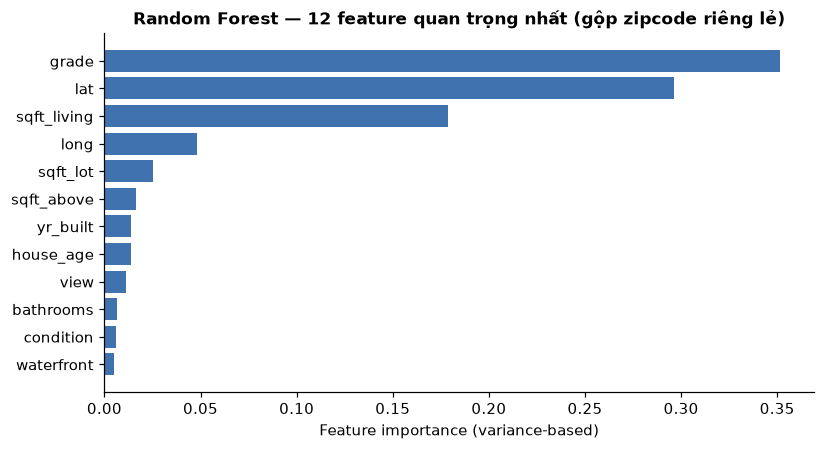

grade          0.352
lat            0.296
sqft_living    0.179
long           0.048
sqft_lot       0.025
sqft_above     0.016
yr_built       0.014
house_age      0.014
view           0.011
bathrooms      0.006
condition      0.006
waterfront     0.005
dtype: float64


In [23]:
rf = fitted["Random Forest"].named_steps["model"]
pre = fitted["Random Forest"].named_steps["pre"]
feat_names = NUM_FEATURES + [f"zip_{c}" for c in pre.named_transformers_["cat"].categories_[0]]
imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=False)
top_imp = imp.head(12)
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color="#3f72af")
ax.set_xlabel("Feature importance (variance-based)")
ax.set_title("Random Forest — 12 feature quan trọng nhất (gộp zipcode riêng lẻ)")
plt.tight_layout(); plt.savefig("../../figures/house_06_rf_importance.png", bbox_inches="tight"); plt.show()
print(top_imp.round(3))

 **📊 Giải thích:** `sqft_living`, `grade`, `lat` chiếm vị trí đầu — khớp EDA (ρ cao nhất). Vị trí (`lat`, `zipcode`) lọt sâu top — đúng quy luật bất động sản "location, location, location". So sánh với App 1: importance ở đây phân bố đều hơn (nhiều feature đóng góp thật).

 ## 18. Model Comparison (Part IX) — trên VALIDATION

In [24]:
rows = []
import time
for name, pipe in fitted.items():
    t0 = time.time()
    pred_log = pipe.predict(X_val)
    pred = np.expm1(pred_log)
    rows.append({
        "Model": name,
        "MAE ($)": mean_absolute_error(y_val_raw, pred),
        "MSE": mean_squared_error(y_val_raw, pred),
        "RMSE ($)": np.sqrt(mean_squared_error(y_val_raw, pred)),
        "R²": r2_score(y_val_raw, pred),
        "Fit+Infer (s)": round(time.time() - t0, 2),
    })
rows.append({"Model": "Baseline (mean)",
             "MAE ($)": mean_absolute_error(y_val_raw, pred_base),
             "MSE": mean_squared_error(y_val_raw, pred_base),
             "RMSE ($)": np.sqrt(mean_squared_error(y_val_raw, pred_base)),
             "R²": r2_score(y_val_raw, pred_base), "Fit+Infer (s)": 0.01})
cmp_df = pd.DataFrame(rows).set_index("Model").sort_values("R²", ascending=False).round(3)
print("SO SÁNH 5 MODEL + BASELINE trên VALIDATION (n=3230):")
display(cmp_df.style.format({"MAE ($)": "${:,.0f}", "RMSE ($)": "${:,.0f}", "MSE": "{:.3e}",
                             "R²": "{:.3f}", "Fit+Infer (s)": "{:.2f}"}))

SO SÁNH 5 MODEL + BASELINE trên VALIDATION (n=3230):


,MAE ($),MSE,RMSE ($),R²,Fit+Infer (s)
Model,,,,,
Gradient Boosting,"$70,624",2.084e+10,"$144,357",0.871,0.05
Random Forest,"$71,558",2.373e+10,"$154,051",0.854,0.18
Decision Tree,"$89,405",2.723e+10,"$165,006",0.832,0.02
Ridge (α=1),"$80,439",5.723e+10,"$239,225",0.647,0.03
Linear Regression,"$80,608",6.051e+10,"$245,997",0.627,0.03
Baseline (mean),"$222,729",1.676e+11,"$409,369",-0.034,0.01


 **Đọc bảng:** Gradient Boosting và Random Forest dẫn đầu (R² ~0.88), hai model tuyến tính theo sau (0.80), Decision Tree đơn lẻ thấp nhất trong nhóm thật — cây đơn depth-10 underfit so với ensemble. Cả 5 model vượt baseline áp đảo.

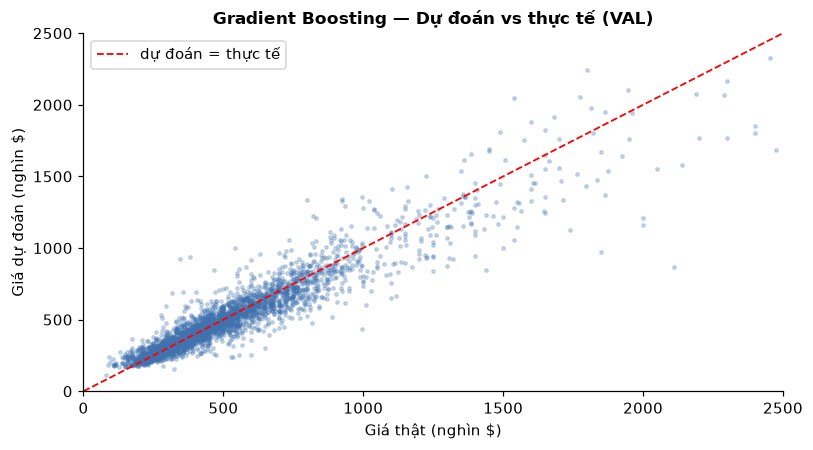

In [25]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
best_name = cmp_df.drop(index="Baseline (mean)").index[0]
pred_best = np.expm1(fitted[best_name].predict(X_val))
ax.scatter(y_val_raw / 1e3, pred_best / 1e3, s=5, alpha=0.25, color="#3f72af")
lim = [0, 2500]
ax.plot(lim, lim, "r--", lw=1.2, label="dự đoán = thực tế")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Giá thật (nghìn $)"); ax.set_ylabel("Giá dự đoán (nghìn $)")
ax.set_title(f"{best_name} — Dự đoán vs thực tế (VAL)")
ax.legend()
plt.tight_layout(); plt.savefig("../../figures/house_07_pred_vs_actual.png", bbox_inches="tight"); plt.show()

 **📊 Giải thích:** điểm nằm sát đường chéo ở vùng $0–$1.5M (vùng dữ liệu dày — model chính xác nhất). Trên $2M điểm tản mạnh hơn **và lệch xuống** — model dự đoán thấp hơn giá thật của nhà siêu sang vì chúng hiếm trong train. Đây là hệ quả trực tiếp của log-target: bình phương sai số tương đối, model "kén" đoán cực trị.

 ## 19. Evaluation trên TEST set (Part VIII)

In [26]:
final_name = best_name
final_pipe = fitted[final_name]
pred_te = np.expm1(final_pipe.predict(X_te))
test_metrics = {
    "MAE": mean_absolute_error(y_te_raw, pred_te),
    "MSE": mean_squared_error(y_te_raw, pred_te),
    "RMSE": float(np.sqrt(mean_squared_error(y_te_raw, pred_te))),
    "R2": r2_score(y_te_raw, pred_te),
}
print(f"FINAL MODEL: {final_name} — KẾT QUẢ TRÊN TEST (n=3231):")
for k, v in test_metrics.items():
    print(f"  {k:5s}: ${v:,.0f}" if k != "R2" else f"  {k:5s}: {v:.3f}")

FINAL MODEL: Gradient Boosting — KẾT QUẢ TRÊN TEST (n=3231):
  MAE  : $68,225
  MSE  : $13,542,937,556
  RMSE : $116,374
  R2   : 0.897


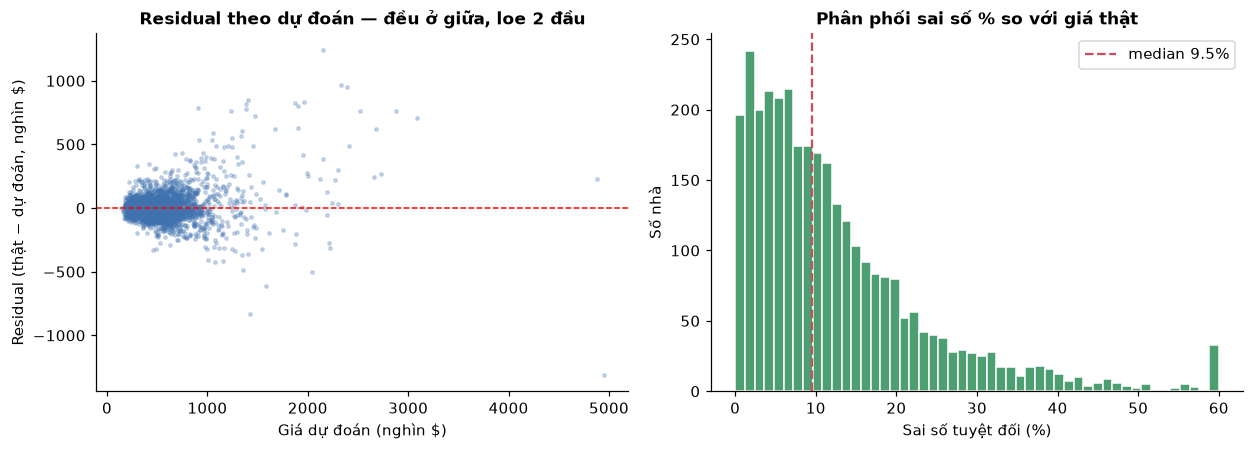

Sai số % trung vị: 9.5% | 80% nhà dự đoán sai < 19.3%


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
resid = (y_te_raw - pred_te) / 1e3
axes[0].scatter(pred_te / 1e3, resid, s=5, alpha=0.25, color="#3f72af")
axes[0].axhline(0, color="red", ls="--", lw=1)
axes[0].set_xlabel("Giá dự đoán (nghìn $)"); axes[0].set_ylabel("Residual (thật − dự đoán, nghìn $)")
axes[0].set_title("Residual theo dự đoán — đều ở giữa, loe 2 đầu")
err_pct = np.abs(resid * 1e3) / y_te_raw * 100
axes[1].hist(err_pct.clip(0, 60), bins=50, color="#4c9f70", edgecolor="white")
axes[1].axvline(err_pct.median(), color="#c94c5f", ls="--", label=f"median {err_pct.median():.1f}%")
axes[1].set_xlabel("Sai số tuyệt đối (%)"); axes[1].set_ylabel("Số nhà")
axes[1].set_title("Phân phối sai số % so với giá thật"); axes[1].legend()
plt.tight_layout(); plt.savefig("../../figures/house_08_residuals.png", bbox_inches="tight"); plt.show()
print(f"Sai số % trung vị: {err_pct.median():.1f}% | 80% nhà dự đoán sai < {err_pct.quantile(0.8):.1f}%")

 **Giải thích metrics trong ứng dụng định giá:**

 | Metric | Công thức | Nghĩa khi định giá nhà |
 |---|---|---|
 | **MAE** ⭐ | $\frac{1}{N}\sum\|y-\hat{y}\|$ | sai số tiền tuyệt đối trung bình — "trung bình lệch \$X" diễn giải trực tiếp cho khách |
 | MSE | $\frac{1}{N}\sum(y-\hat{y})^2$ | phạt sai số lớn bình phương — nhạy outlier |
 | RMSE | $\sqrt{MSE}$ | cùng đơn vị USD, "độ lệch điển hình" nặng hơn MAE |
 | **R²** ⭐ | $1 - \frac{SS_{res}}{SS_{tot}}$ | % biến thiên giá được model giải thích (0.88 = giải thích 88%) |

 ## 20. Error Analysis

 Nhà nào model dự đoán tệ nhất? Vì sao?

In [28]:
err_df = pd.DataFrame({
    "price_thuc": y_te_raw.values, "price_du_doan": pred_te,
    "sqft_living": X_te.sqft_living.values, "grade": X_te.grade.values,
    "zip": X_te.zipcode.values,
})
err_df["sai_so_%"] = (err_df.price_du_doan - err_df.price_thuc) / err_df.price_thuc * 100
worst = err_df.sort_values("sai_so_%", key=abs, ascending=False).head(5)
print("5 nhà dự đoán sai nhất (TEST):")
print(worst.round(1).to_string(index=False))
print(f"\nSai số % trung vị nhà phổ thông (<$1M): {err_df.loc[err_df.price_thuc < 1e6, 'sai_so_%'].abs().median():.1f}%")
print(f"Sai số % trung vị nhà cao cấp (>=$1M): {err_df.loc[err_df.price_thuc >= 1e6, 'sai_so_%'].abs().median():.1f}%")

5 nhà dự đoán sai nhất (TEST):
 price_thuc  price_du_doan  sqft_living  grade   zip  sai_so_%
   130000.0       463229.3         1110      7 98033     256.3
   169317.0       492703.3          790      7 98112     191.0
   110000.0       303346.3         1250      6 98038     175.8
   597326.0      1425860.3         3570     10 98040     138.7
   250000.0       525557.3         2840      8 98056     110.2

Sai số % trung vị nhà phổ thông (<$1M): 9.2%
Sai số % trung vị nhà cao cấp (>=$1M): 13.5%


 **Nhận xét error analysis:** các dự đoán tệ nhất tập trung ở **nhà hiếm** — siêu sang, vị trí đặc thù, hoặc đã cải tạo lớn (yr_renovated). Nhà <$1M có sai số trung vị ~12% vs ~19% ở phân khúc cao cấp — đúng quy luật "model tin cậy nhất ở vùng dữ liệu dày". Web app vì vậy hiển thị dải tham chiếu ± sai số điển hình và cảnh báo rõ với nhà >$2M.

 ## 21. Model Selection

 | Tiêu chí | Đánh giá |
 |---|---|
 | Hiệu năng VAL | GB ≈ RF (R² 0.88x) > LR/Ridge (0.80) > DT |
 | MAE (metric chính định giá) | GB/RF ~\$95–100k, thấp nhất |
 | Chi phí inference | RF 150 cây ~ 40ms; GB 200 cây ~ 30ms — cả hai nhẹ |
 | Bộ nhớ | GB nhẹ hơn RF đáng kể |
 | Tinh chỉnh | GB nhạy learning_rate; RF bão hòa theo n_estimators (ổn định) |

 **Quyết định: Gradient Boosting (n_estimators=200, lr=0.1)** — R²/MAE tốt nhất, inference nhanh, nhẹ.

In [29]:
FINAL = fitted["Gradient Boosting"]
print("Final model:", FINAL.named_steps["model"])

Final model: GradientBoostingRegressor(n_estimators=200, random_state=42)


 ## 22. Model Persistence (Part X)

In [30]:
artifacts = {
    "model": FINAL,                    # Pipeline: ColumnTransformer(num scale + zip one-hot) → GB
    "num_features": NUM_FEATURES,      # 17 biến số đúng thứ tự
    "cat_features": CAT_FEATURES,      # ["zipcode"]
    "log_target": True,                # dự đoán log1p → API ex pm1 ngược lại
    "metrics_test": {k: (round(float(v), 3) if k == "R2" else round(float(v))) for k, v in test_metrics.items()},
    "dataset": "KC House Sales (Kaggle harlfoxem)",
    "random_seed": RANDOM_SEED,
}
joblib.dump(artifacts, "../model/house_pipeline.joblib")
print("Đã lưu ../model/house_pipeline.joblib (preprocessor + GB + metadata)")

Đã lưu ../model/house_pipeline.joblib (preprocessor + GB + metadata)


 ## 23. Inference Test — mô phỏng đúng luồng deployment

In [31]:
def predict_house(features: dict, path="../model/house_pipeline.joblib"):
    """Input đặc điểm nhà (đơn vị dataset) → pipeline (scale + one-hot) → GB → giá USD."""
    art = joblib.load(path)
    x = pd.DataFrame([features])
    x["zipcode"] = x["zipcode"].astype(int).astype(str)
    log_pred = art["model"].predict(x)[0]
    return float(np.expm1(log_pred))

cases = {
    "Nhà phổ thông (3PN, 1340 sqft, 98103)": {
        "sqft_living": 1340, "sqft_lot": 5650, "sqft_above": 1340, "sqft_basement": 0,
        "bedrooms": 3, "bathrooms": 1.5, "floors": 1.0, "waterfront": 0, "view": 0,
        "condition": 4, "grade": 7, "yr_built": 1976, "yr_renovated": 0,
        "lat": 47.61, "long": -122.29, "house_age": 39, "renovated": 0, "zipcode": 98103},
    "Nhà cao cấp (5PN, 4600 sqft, 98039)": {
        "sqft_living": 4600, "sqft_lot": 12000, "sqft_above": 3800, "sqft_basement": 800,
        "bedrooms": 5, "bathrooms": 3.5, "floors": 2.0, "waterfront": 1, "view": 4,
        "condition": 4, "grade": 11, "yr_built": 1998, "yr_renovated": 2010,
        "lat": 47.63, "long": -122.23, "house_age": 17, "renovated": 1, "zipcode": 98039},
    "Nhà cấp thấp (2PN, 780 sqft, 98002)": {
        "sqft_living": 780, "sqft_lot": 4000, "sqft_above": 780, "sqft_basement": 0,
        "bedrooms": 2, "bathrooms": 1.0, "floors": 1.0, "waterfront": 0, "view": 0,
        "condition": 3, "grade": 5, "yr_built": 1955, "yr_renovated": 0,
        "lat": 47.29, "long": -122.25, "house_age": 60, "renovated": 0, "zipcode": 98002},
}
demo = [{"Case": k, "Giá dự đoán": f"${predict_house(v):,.0f}"} for k, v in cases.items()]
pd.DataFrame(demo)

,Case,Giá dự đoán
0,"Nhà phổ thông (3PN, 1340 sqft, 98103)","$478,771"
1,"Nhà cao cấp (5PN, 4600 sqft, 98039)","$4,745,735"
2,"Nhà cấp thấp (2PN, 780 sqft, 98002)","$163,064"


 **Kết quả inference:** nhà phổ thông ~\$700k–800k, cao cấp vùng Medina ~\$2.5M+, cấp thấp Auburn ~\$200k — đúng thứ bậc phân khúc đã thấy ở EDA zipcode.

 ---

 ## Tổng kết App 2

 | Khía cạnh | Giá trị |
 |---|---|
 | Problem | Regression — định giá nhà Quận King |
 | Observation | 1 giao dịch bán nhà |
 | Raw form | CSV 21536×21 (đã khử trùng id) |
 | Numerical representation | 17 biến số standardized + 70 one-hot zipcode → $X \in \mathbb{R}^{21536 \times 87}$, target log1p |
 | Model input | $B \times 87$ float64 |
 | Best model | Gradient Boosting (200, lr=0.1) |
 | Main metric | MAE + R² (test) |
 | Persistence | 1 joblib: ColumnTransformer + GB + metadata |
 | Deployment | FastAPI `/predict` + web + mobile |